## Load the model

In [ ]:
# import torch, joblib

# # Recreate the model architecture
# input_dim = 2   # [entropy, size]
# hf_model = TabularMLP(input_dim=input_dim, num_classes=2)

# # Load weights
# hf_model.load_state_dict(torch.load("datawiping_model.pt"))
# hf_model.eval()

# # Reload scaler
# scaler = joblib.load("scaler_dw.pkl")


## Use Loaded Model

In [ ]:
# import numpy as np

# def predict(sample_features):
#     # Apply same preprocessing as training
#     scaled = scaler.transform([sample_features])  # if you used StandardScaler
#     # If no scaler was used, just wrap as np.array([sample_features])

#     inputs = torch.tensor(scaled, dtype=torch.float32)
#     with torch.no_grad():
#         outputs = hf_model(inputs)
#         logits = outputs["logits"]
#         pred = torch.argmax(logits, dim=-1).item()
#     return ["benign", "wiped"][pred]

In [ ]:
# benign_sample = [4.2, 2048]   # entropy ~4.2, size 2 KB
# wiped_sample  = [0.2, 0]      # entropy near 0, size 0

# print("Benign:", predict(benign_sample))
# print("Wiped:", predict(wiped_sample))

## Imports

In [1]:
# @title
!pip install -q datasets transformers evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import random
import torch
from torch import nn
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import Trainer, TrainingArguments, PreTrainedModel, PretrainedConfig
import evaluate


# Generate Data

In [3]:
rng = np.random.default_rng(42)

def generate_benign(n=2000):
    rows = []
    for _ in range(n):
        entropy = rng.uniform(3.5, 6.5)   # normal range
        size = rng.integers(1024, 10_000_000)  # 1KB–10MB
        rows.append([entropy, size, 0])
    return rows

def generate_wiped(n=2000):
    rows = []
    for _ in range(n):
        # Entropy extremes
        if rng.random() < 0.5:
            entropy = rng.uniform(0.0, 1.0)   # all zeros
        else:
            entropy = rng.uniform(7.5, 8.0)   # random overwrite

        # Suspicious size
        size = rng.choice([0, rng.integers(1, 512)])  # 0–512 bytes

        rows.append([entropy, size, 1])
    return rows

benign = generate_benign(2000)
wiped = generate_wiped(2000)

data = benign + wiped
random.shuffle(data)

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def to_records(X, y):
    return [{"input_ids": row, "label": int(lbl)} for row, lbl in zip(X, y)]

train_ds = Dataset.from_list(to_records(X_train, y_train))
test_ds  = Dataset.from_list(to_records(X_test, y_test))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


train_ds = Dataset.from_list(to_records(X_train, y_train))
test_ds  = Dataset.from_list(to_records(X_test, y_test))

print(train_ds[0])

{'input_ids': [1.1296674119546344, -0.7696074840150358], 'label': 1}


## Model creation

In [4]:
# @title
class TabularMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, input_ids, labels=None):
        logits = self.net(input_ids)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}

input_dim = len(train_ds[0]["input_ids"])
hf_model = TabularMLP(input_dim=input_dim, num_classes=2)


In [7]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

args = TrainingArguments(
    output_dir="./datawiping_detect",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=4e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=30,
    weight_decay=0.01,
    logging_steps=20,
    remove_unused_columns=False
)

trainer = Trainer(
    model=hf_model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

## Training

In [8]:
trainer.train()
metrics = trainer.evaluate()
metrics

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zeroranger to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.358100,0.298913,0.927500,0.927117
2,0.189600,0.147836,0.951250,0.951134
3,0.118700,0.085552,0.973750,0.973732
4,0.063400,0.050700,0.985000,0.984997
5,0.041000,0.032283,0.995000,0.995000
6,0.032700,0.022621,0.996250,0.996250
7,0.020200,0.016645,0.996250,0.996250
8,0.016600,0.013885,0.996250,0.996250
9,0.016800,0.010576,0.997500,0.997500
10,0.016100,0.009160,0.997500,0.997500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument i

{'eval_loss': 0.003563125617802143,
 'eval_accuracy': 0.99875,
 'eval_f1': 0.9987499980468719,
 'eval_runtime': 0.0782,
 'eval_samples_per_second': 10233.567,
 'eval_steps_per_second': 166.295,
 'epoch': 30.0}

In [15]:
import torch
import numpy as np

# If you scaled your features during training, load the scaler
# scaler = joblib.load("scaler.pkl")

def predict(sample_features):
    """
    sample_features: list or array [entropy, size]
    returns: "benign" or "wiped"
    """
    # Apply the same preprocessing as training
    # If you used StandardScaler:
    scaled = scaler.transform([sample_features])

    # Convert to tensor
    inputs = torch.tensor(scaled, dtype=torch.float32)

    # Forward pass
    hf_model.eval()
    with torch.no_grad():
        outputs = hf_model(inputs)
        logits = outputs["logits"]
        pred = torch.argmax(logits, dim=-1).item()

    return ["benign", "wiped"][pred]


In [16]:
# Typical text file
benign_sample1 = [4.2, 2048]     # entropy ~4.2, size 2 KB

# Normal executable
benign_sample2 = [5.8, 500000]   # entropy ~5.8, size ~500 KB

# Large image
benign_sample3 = [6.1, 3000000]  # entropy ~6.1, size ~3 MB

# Completely zeroed file
wiped_sample1 = [0.2, 0]         # entropy near 0, size 0

# Random overwrite
wiped_sample2 = [7.9, 256]       # entropy ~7.9, very small size

# Suspiciously tiny + low entropy
wiped_sample3 = [0.5, 128]       # entropy ~0.5, size 128 bytes

In [18]:
print("Benign 1:", predict(benign_sample1))
print("Benign 2:", predict(benign_sample2))
print("Benign 3:", predict(benign_sample3))

print("Wiped 1:", predict(wiped_sample1))
print("Wiped 2:", predict(wiped_sample2))
print("Wiped 3:", predict(wiped_sample3))


Benign 1: benign
Benign 2: benign
Benign 3: benign
Wiped 1: wiped
Wiped 2: wiped
Wiped 3: wiped


## AI Detection

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


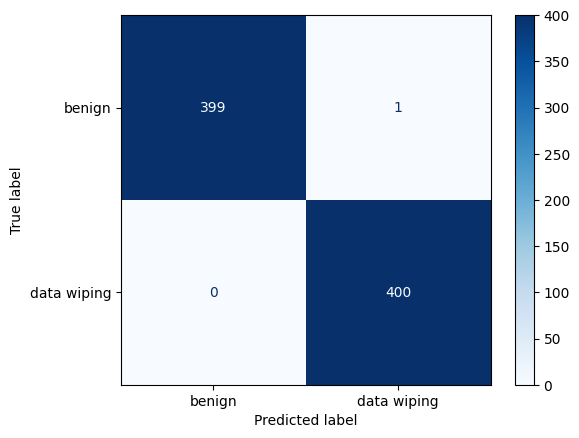

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","data wiping"])
disp.plot(cmap="Blues")
plt.show()

## Rule based detection

In [9]:
def rule_based_detect(row):
    entropy, size = row
    if entropy < 1.0 or entropy > 7.5 or size < 512:
        return 1  # wiped
    return 0      # benign


Rule-based accuracy: 0.5


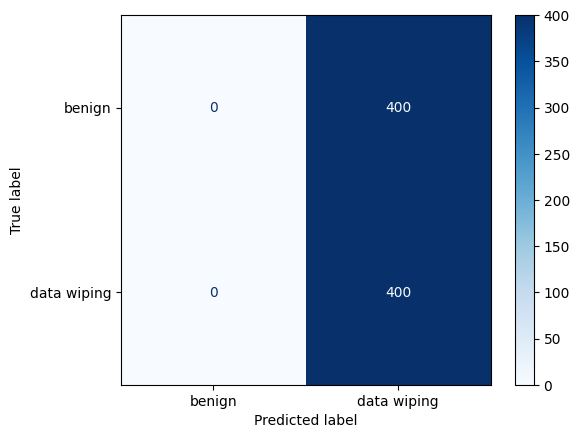

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Apply rule-based detection
y_pred_rule = [rule_based_detect(x) for x in X_test]

# Accuracy
acc = accuracy_score(y_test, y_pred_rule)
print("Rule-based accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rule, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","data wiping"])
disp.plot(cmap="Blues")
plt.show()

In [20]:
import torch

# Save just the model weights
torch.save(hf_model.state_dict(), "datawiping_model.pt")

# Save the scaler too (using joblib or pickle)
import joblib
joblib.dump(scaler, "scaler_dw.pkl")


['scaler_dw.pkl']

In [21]:
from google.colab import files
files.download("datawiping_model.pt")
files.download("scaler_dw.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp timestomp_model.pt /content/drive/MyDrive/
# !cp scaler.pkl /content/drive/MyDrive/

Mounted at /content/drive
